#**1. Carga y preparación de datos**


In [9]:
import pandas as pd
import requests

url = "https://raw.githubusercontent.com/alura-cursos/challenge2-data-science-LATAM/main/TelecomX_Data.json"

data = requests.get(url).json()

df = pd.json_normalize(data)

df.head()

,customerID,Churn,customer.gender,customer.SeniorCitizen,customer.Partner,customer.Dependents,customer.tenure,phone.PhoneService,phone.MultipleLines,internet.InternetService,...,internet.OnlineBackup,internet.DeviceProtection,internet.TechSupport,internet.StreamingTV,internet.StreamingMovies,account.Contract,account.PaperlessBilling,account.PaymentMethod,account.Charges.Monthly,account.Charges.Total
0,0002-ORFBO,No,Female,0,Yes,Yes,9,Yes,No,DSL,...,Yes,No,Yes,Yes,No,One year,Yes,Mailed check,65.6,593.3
1,0003-MKNFE,No,Male,0,No,No,9,Yes,Yes,DSL,...,No,No,No,No,Yes,Month-to-month,No,Mailed check,59.9,542.4
2,0004-TLHLJ,Yes,Male,0,No,No,4,Yes,No,Fiber optic,...,No,Yes,No,No,No,Month-to-month,Yes,Electronic check,73.9,280.85
3,0011-IGKFF,Yes,Male,1,Yes,No,13,Yes,No,Fiber optic,...,Yes,Yes,No,Yes,Yes,Month-to-month,Yes,Electronic check,98.0,1237.85
4,0013-EXCHZ,Yes,Female,1,Yes,No,3,Yes,No,Fiber optic,...,No,No,Yes,Yes,No,Month-to-month,Yes,Mailed check,83.9,267.4


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7267 entries, 0 to 7266
Data columns (total 6 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   customerID  7267 non-null   object
 1   Churn       7267 non-null   object
 2   customer    7267 non-null   object
 3   phone       7267 non-null   object
 4   internet    7267 non-null   object
 5   account     7267 non-null   object
dtypes: object(6)
memory usage: 340.8+ KB


#**2. Exploración inicial**

In [11]:
df.isnull().sum()

,0
customerID,0
Churn,0
customer.gender,0
customer.SeniorCitizen,0
customer.Partner,0
customer.Dependents,0
customer.tenure,0
phone.PhoneService,0
phone.MultipleLines,0
internet.InternetService,0


In [12]:
df.duplicated().sum()

np.int64(0)

In [13]:
df['Churn'].value_counts()

,count
Churn,
No,5174
Yes,1869
,224


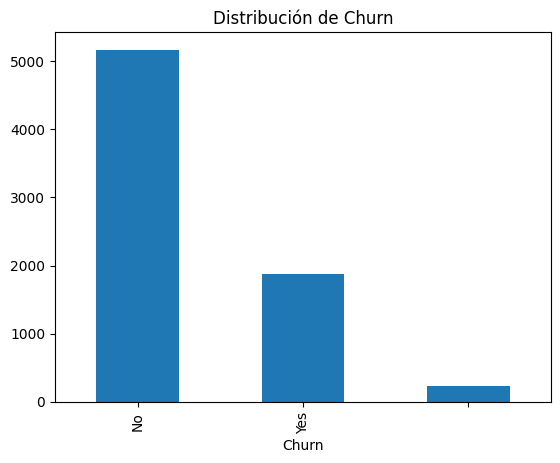

In [14]:
import matplotlib.pyplot as plt

df['Churn'].value_counts().plot(kind='bar')
plt.title("Distribución de Churn")
plt.show()

#**3. Análisis descriptivo**

In [16]:
df['Churn'].unique()


array(['No', 'Yes', ''], dtype=object)

In [17]:
df['Churn'].value_counts(normalize=True) * 100


,proportion
Churn,
No,71.198569
Yes,25.719004
,3.082427


In [18]:
pd.crosstab(df['account.Contract'], df['Churn'])


Churn,,No,Yes
account.Contract,,,
Month-to-month,130,2220,1655
One year,46,1307,166
Two year,48,1647,48


In [19]:
pd.crosstab(df['account.PaymentMethod'], df['Churn'])


Churn,,No,Yes
account.PaymentMethod,,,
Bank transfer (automatic),45,1286,258
Credit card (automatic),46,1290,232
Electronic check,80,1294,1071
Mailed check,53,1304,308


In [20]:
df.groupby('Churn')['account.Charges.Monthly'].mean()


,account.Charges.Monthly
Churn,
,63.412277
No,61.265124
Yes,74.441332


In [21]:
df.groupby('Churn')['customer.tenure'].mean()


,customer.tenure
Churn,
,31.571429
No,37.569965
Yes,17.979133


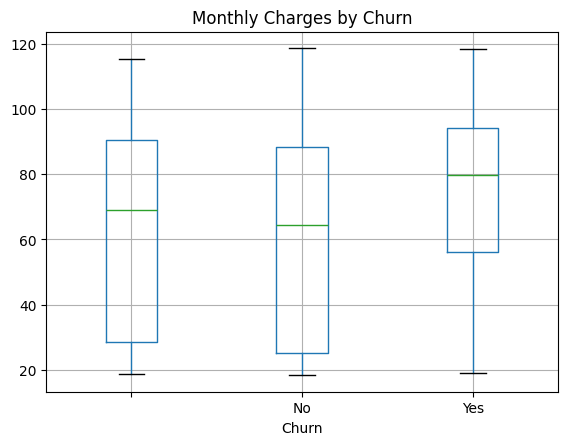

In [22]:
import matplotlib.pyplot as plt

df.boxplot(column='account.Charges.Monthly', by='Churn')
plt.title("Monthly Charges by Churn")
plt.suptitle("")
plt.show()


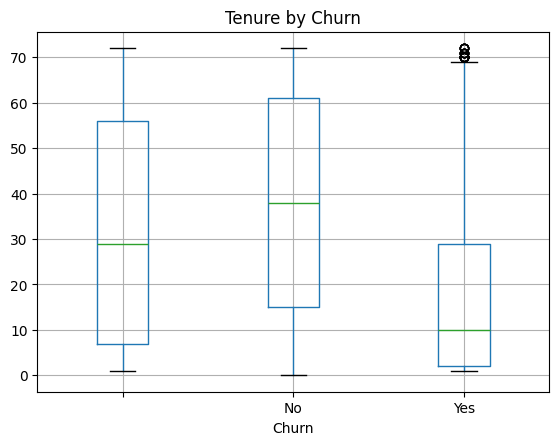

In [23]:
df.boxplot(column='customer.tenure', by='Churn')
plt.title("Tenure by Churn")
plt.suptitle("")
plt.show()


#**4. Ingeniería de variables**

In [24]:
df.groupby('Churn')['account.Charges.Monthly'].mean()


,account.Charges.Monthly
Churn,
,63.412277
No,61.265124
Yes,74.441332


In [25]:
df.groupby('Churn')['customer.tenure'].mean()


,customer.tenure
Churn,
,31.571429
No,37.569965
Yes,17.979133


In [26]:
pd.crosstab(df['internet.InternetService'], df['Churn'], normalize='index') * 100


Churn,,No,Yes
internet.InternetService,,,
DSL,2.692926,78.858521,18.448553
Fiber optic,3.189493,56.253909,40.556598
No,3.478811,89.373814,7.147375


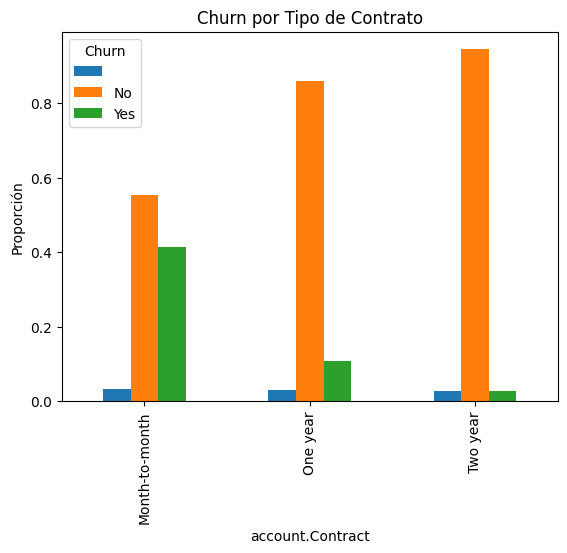

In [27]:
pd.crosstab(df['account.Contract'], df['Churn'], normalize='index').plot(kind='bar')
plt.title("Churn por Tipo de Contrato")
plt.ylabel("Proporción")
plt.show()


In [28]:
df['Churn'] = df['Churn'].map({'No':0, 'Yes':1})


In [29]:
df['Churn'].unique()


array([ 0.,  1., nan])

#**5. Análisis de Correlación**

In [30]:
df['DailyCharges'] = df['account.Charges.Monthly'] / 30


In [31]:
services = [
    'phone.PhoneService',
    'internet.OnlineSecurity',
    'internet.OnlineBackup',
    'internet.DeviceProtection',
    'internet.TechSupport',
    'internet.StreamingTV',
    'internet.StreamingMovies'
]

for col in services:
    df[col] = df[col].map({'Yes':1, 'No':0})


In [32]:
df['TotalServices'] = df[services].sum(axis=1)


In [33]:
df[['Churn',
    'DailyCharges',
    'account.Charges.Monthly',
    'customer.tenure',
    'TotalServices']].corr()


,Churn,DailyCharges,account.Charges.Monthly,customer.tenure,TotalServices
Churn,1.000000,0.193356,0.193356,-0.352229,-0.085963
DailyCharges,0.193356,1.000000,1.000000,0.247982,0.766372
account.Charges.Monthly,0.193356,1.000000,1.000000,0.247982,0.766372
customer.tenure,-0.352229,0.247982,0.247982,1.000000,0.497074
TotalServices,-0.085963,0.766372,0.766372,0.497074,1.000000


#**EXTRA**



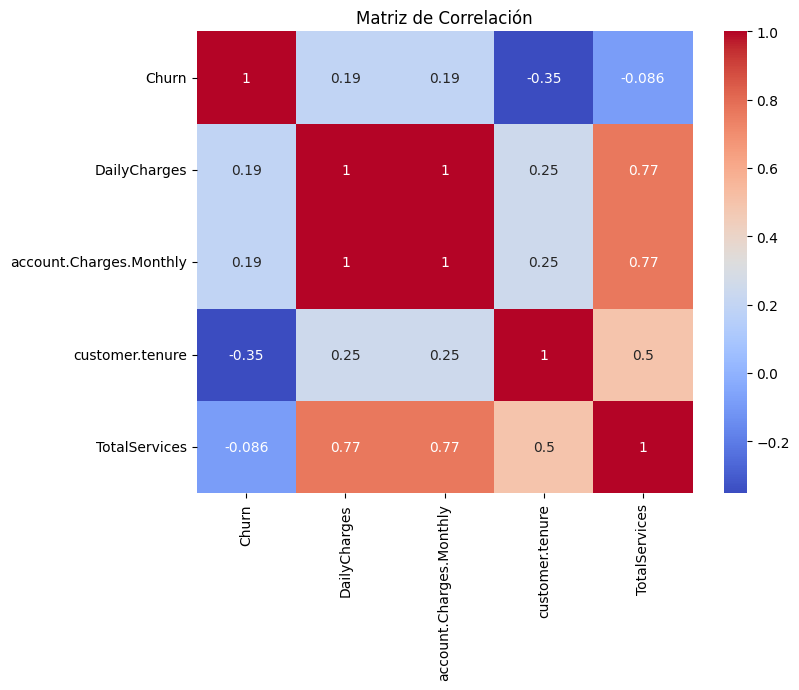

In [34]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(8,6))
sns.heatmap(
    df[['Churn',
        'DailyCharges',
        'account.Charges.Monthly',
        'customer.tenure',
        'TotalServices']].corr(),
    annot=True,
    cmap='coolwarm'
)
plt.title("Matriz de Correlación")
plt.show()


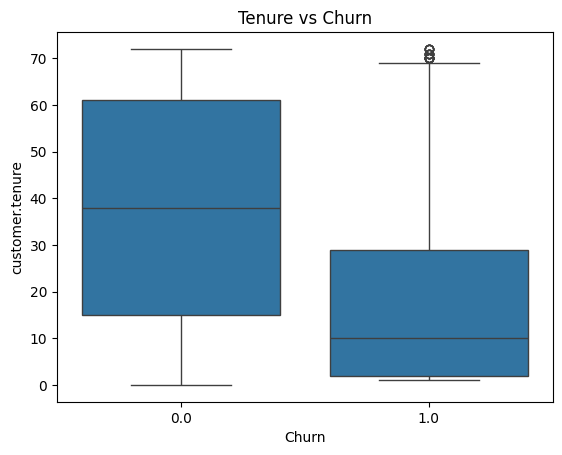

In [35]:
sns.boxplot(x='Churn', y='customer.tenure', data=df)
plt.title("Tenure vs Churn")
plt.show()


#**Informe Final - Análisis de Evasión de Clientes (Churn)**

##**1. Introducción**

La evasión de clientes, conocida como Churn, representa uno de los principales desafíos para las empresas de telecomunicaciones, ya que impacta directamente en los ingresos y en la estabilidad del negocio.

El objetivo de este análisis es identificar los factores que influyen en la cancelación del servicio por parte de los clientes de TelecomX, utilizando técnicas de análisis exploratorio de datos (EDA) para detectar patrones, relaciones y posibles variables críticas.

Comprender qué características tienen los clientes que abandonan el servicio permite diseñar estrategias de retención más efectivas y reducir pérdidas económicas.

#**2. Limpieza y Tratamiento de Datos**

Para realizar el análisis, se siguieron los siguientes pasos:

**##Importación de datos**

* Se cargaron los datos desde un archivo JSON alojado en GitHub.

* Se utilizó pd.json_normalize() para estructurar correctamente las columnas anidadas.

**##Exploración inicial**

* Se verificaron valores nulos con df.isnull().sum().

* Se revisaron registros duplicados con df.duplicated().sum().

* Se analizó la distribución de la variable objetivo Churn.

**##Transformaciones realizadas**

* Se convirtió la variable Churn a formato numérico (0 = No, 1 = Yes).

* Se creó la variable DailyCharges dividiendo el cargo mensual entre 30.

* Se transformaron variables de servicios adicionales a formato binario (0/1).

* Se creó la variable TotalServices, que representa la cantidad total de servicios contratados por cliente.

Estas transformaciones permitieron facilitar el análisis estadístico y la matriz de correlación.

#**Análisis Exploraciones de Datos (EDA)**

**Distribución de Churn**

El análisis mostró que:

* Existe una proporción menor de clientes que cancelan en comparación con los que permanecen.

* Sin embargo, el porcentaje de evasión es significativo y requiere atención estratégica.

**Tipo de Contrato**

El cruce entre account.Contract y Churn reveló que:

* Los contratos mensuales (Month-to-month) presentan una mayor tasa de cancelación.

* Los contratos de 1 o 2 años muestran menor churn.

Los clientes con contratos a corto plazo tienen menor compromiso y mayor probabilidad de cancelar.

**Cargos Mensuales:**

El boxplot mostró que:

* Los clientes que cancelan tienden a tener cargos mensuales más altos en promedio.

* Existe mayor dispersión en los valores de quienes abandonan.

Tarifas elevadas podrían estar asociadas con mayor probabilidad de cancelación.

**Antigüedad del cliente (Tenure)**

El análisis de customer.tenure indicó que:

* Los clientes que cancelan suelen tener menor antigüedad.

* Clientes con mayor tiempo en la empresa tienden a permanecer.

El riesgo de churn es mayor en las primeras etapas de la relación con el cliente.

**Servicios de Internet y Servicios Adicionales**

El análisis de internet.InternetService y TotalServices mostró que:

* Los clientes con menos servicios adicionales presentan mayor tasa de cancelación.

* Tener más servicios contratados parece reducir la probabilidad de churn.

A mayor integración del cliente con los servicios, menor probabilidad de abandono.

**Matriz de Correlación**

La matriz de correlación mostró:

* Correlación negativa entre tenure y Churn → mayor antigüedad, menor churn.

* Correlación positiva entre Monthly Charges y Churn.

* TotalServices muestra relación moderada con la permanencia.

Aunque las correlaciones no son extremadamente altas, sí evidencian patrones relevantes para el negocio.

#**Conclusiones e Insights**

Del análisis realizado se concluye que:

1. El churn está asociado principalmente con:

* Contratos mensuales.

* Alta tarifa mensual.

* Baja antigüedad.

* Menor número de servicios contratados.

2. Los clientes nuevos representan el grupo de mayor riesgo.

3. Los contratos de largo plazo funcionan como mecanismo de retención natural.

4. La diversificación de servicios fortalece la relación con el cliente y reduce la evasión.

Estos hallazgos permiten identificar perfiles de alto riesgo y diseñar estrategias preventivas.

#**Recomendaciones Estratégicas**

Basado en los resultados obtenidos, se sugieren las siguientes acciones:

**1. Incentivar contratos de largo plazo**

* Ofrecer descuentos o beneficios exclusivos para planes anuales o bianuales.

* Diseñar campañas de migración de clientes mensuales a planes extendidos.

**2. Revisar estructura de precios**

* Analizar si los cargos más altos generan percepción negativa de valor.

* Crear paquetes más atractivos para clientes de alto costo.

**3. Estrategia de retención temprana**

* Implementar seguimiento personalizado durante los primeros meses.

* Ofrecer promociones especiales a clientes nuevos.

**4. Promover venta cruzada**

* Incentivar la contratación de servicios adicionales.

* Crear bundles atractivos que aumenten el valor percibido.

**5. Implementar modelo predictivo**

Como siguiente paso, se recomienda desarrollar un modelo de Machine Learning para predecir churn y segmentar clientes en riesgo antes de que cancelen.

#**Conclusión**

Este análisis demuestra que la evasión de clientes no ocurre al azar, sino que responde a patrones claros relacionados con contrato, antigüedad, costos y servicios contratados.

La información obtenida permite transformar datos en decisiones estratégicas, alineadas con la reducción del churn y la mejora en la retención de clientes.